In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [6]:
df = pd.read_csv('car_data.csv')

In [7]:
print(df.head())
print(df.info())

   city_mpg                        class  combination_mpg  cylinders  \
0        25                  midsize car               29        4.0   
1        26                  midsize car               30        4.0   
2        25  small sport utility vehicle               27        4.0   
3        26  small sport utility vehicle               29        4.0   
4        26  small sport utility vehicle               28        4.0   

   displacement drive fuel_type  highway_mpg   make     model transmission  \
0           2.5   fwd       gas           36  mazda         6            m   
1           2.5   fwd       gas           37  mazda         6            a   
2           2.5   fwd       gas           31  mazda  cx-5 2wd            a   
3           2.0   fwd       gas           34  mazda  cx-5 2wd            m   
4           2.0   fwd       gas           32  mazda  cx-5 2wd            a   

   year  
0  2014  
1  2014  
2  2014  
3  2014  
4  2014  
<class 'pandas.core.frame.DataFrame'>


In [8]:
print(df.describe())

         city_mpg  combination_mpg   cylinders  displacement  highway_mpg  \
count  550.000000       550.000000  548.000000    548.000000   550.000000   
mean    21.460000        24.069091    5.315693      2.931752    28.609091   
std      8.147392         7.478369    1.759999      1.248419     6.832228   
min     11.000000        14.000000    3.000000      1.200000    18.000000   
25%     17.000000        20.000000    4.000000      2.000000    24.000000   
50%     20.000000        23.000000    4.000000      2.500000    28.000000   
75%     24.000000        27.000000    6.000000      3.500000    32.000000   
max    126.000000       112.000000   12.000000      6.800000   102.000000   

              year  
count   550.000000  
mean   2019.000000  
std       3.165156  
min    2014.000000  
25%    2016.000000  
50%    2019.000000  
75%    2022.000000  
max    2024.000000  


In [9]:
print(df.isnull().sum())

city_mpg           0
class              0
combination_mpg    0
cylinders          2
displacement       2
drive              0
fuel_type          0
highway_mpg        0
make               0
model              0
transmission       0
year               0
dtype: int64


In [11]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [12]:
if 'Car_Name' in df.columns:
    df.drop('Car_Name', axis=1, inplace=True)

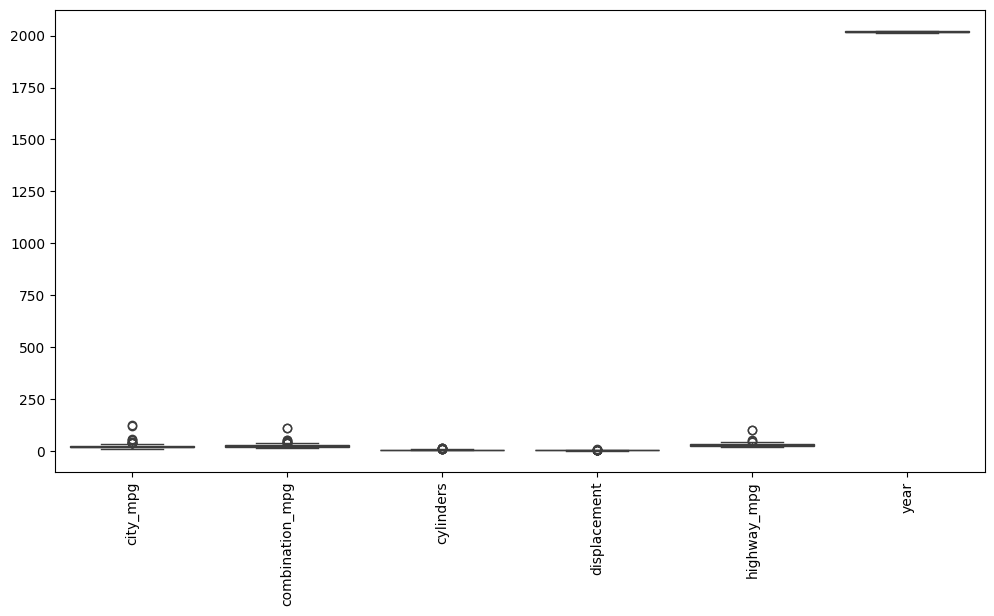

In [16]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

In [22]:
numeric_df = df.select_dtypes(include=['number'])

In [23]:
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

In [24]:
df = df[~((numeric_df < (Q1 - 1.5 * IQR)) | 
          (numeric_df > (Q3 + 1.5 * IQR))).any(axis=1)]

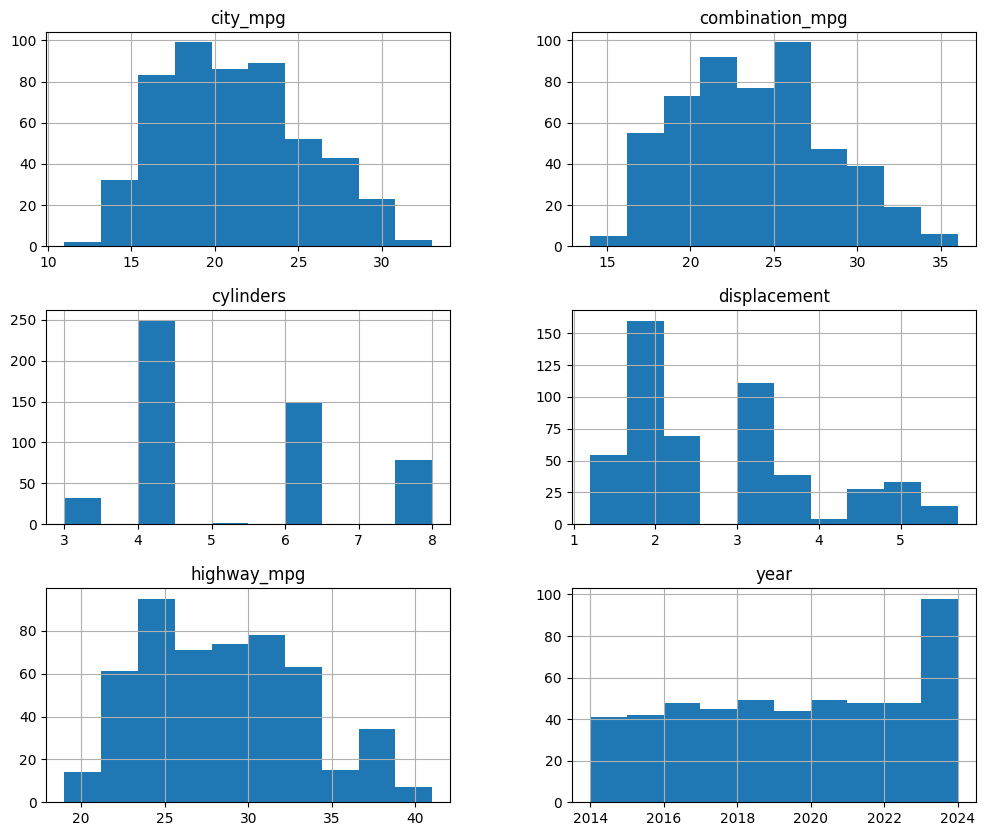

In [25]:
df.hist(figsize=(12,10))
plt.show()

In [27]:
numeric_df = df.select_dtypes(include=['number'])

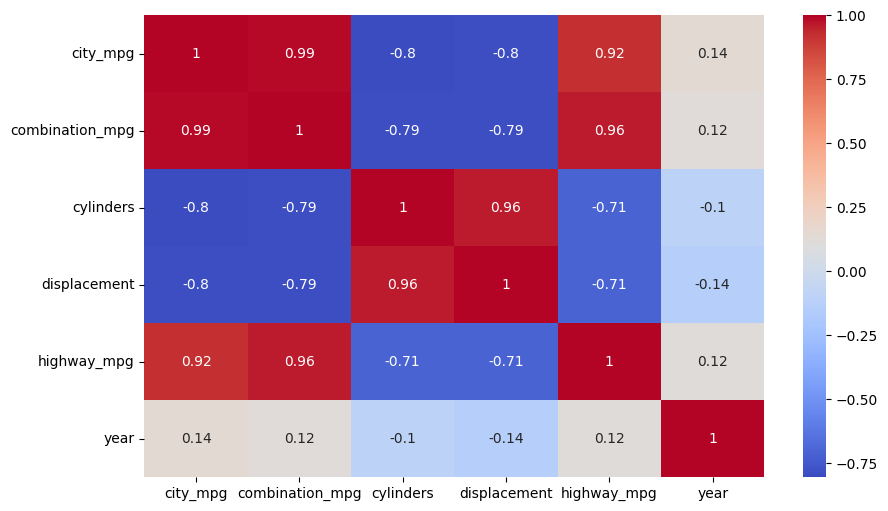

In [28]:
plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [32]:
corr_matrix = numeric_df.corr().abs()

In [33]:
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))


In [34]:
to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]

In [35]:
print("Dropping columns:", to_drop)

Dropping columns: ['combination_mpg', 'displacement', 'highway_mpg']


In [36]:
df.drop(columns=to_drop, inplace=True)

C:\Users\vignesh\AppData\Local\Temp\ipykernel_24544\2384343446.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=to_drop, inplace=True)


In [46]:
df.columns = df.columns.str.lower()
print(df.columns)


Index(['city_mpg', 'class', 'cylinders', 'drive', 'fuel_type', 'make', 'model',
       'transmission', 'year'],
      dtype='object')


In [49]:
print(X_train.dtypes)

class            object
cylinders       float64
drive            object
fuel_type        object
make             object
model            object
transmission     object
year              int64
dtype: object


In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [54]:
print(df.select_dtypes(include=['object']).columns)

Index([], dtype='object')


In [57]:
X = df.drop('city_mpg', axis=1)  
y = df['city_mpg']



In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [59]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [60]:
y_pred = model.predict(X_test)

print("Predictions:", y_pred[:5])

Predictions: [19.31767433 17.05271692 20.34608268 25.73376756 27.59769814]


In [66]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


In [67]:
print("Mean Squared Error:", mse)
print("R² Score:", r2)

Mean Squared Error: 2.4414432920685014
R² Score: 0.8673253704178034
